In [11]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [12]:
import warnings
warnings.simplefilter('ignore')

import numpy as np
import matplotlib.pyplot as plt
from lora_playground.loader import load_runs

# opc_1b diagnostics — chord-tight k=1 vs chord-tight-clean k=2

Companion to `notebooks/opc_1b_leaderboard.ipynb`. The leaderboard summarizes finals; this notebook walks the per-step diagnostics for the **chord-tight (k=1)** vs **chord-tight-clean (k=2)** rows so you can inspect where they diverge.

Background: at packed_v1's 4k horizon, k=1 ≈ k=2 (within 1σ). At the 1B phase-L 9k horizon, **k=2 leads k=1 through step ~2500, then falls behind** (12σ regression by step 9000). This notebook lets you see what changes between the two halves of training.

Scope per rank (r ∈ {16, 64, 256}):
- chord-tight k=1, ns_form='gram', polar='ns', vanilla (no htmuon/SSC), phase-L lr sweep, 9k-step runs.
- chord-tight-clean k=2, same filters.

Panels (same `_max` / `_min` aggregate policy as `spectral_chord_diag` — medians hide outliers):
- γ_A_max / γ_B_max (log)
- frac_dA_through_B_max / frac_dB_through_A_max
- σ_max(A), σ_max(B) (from `SA_max_max`, `SB_max_max`)
- ‖dA‖_F_max / ‖dB‖_F_max (log) and ‖B‖_F_max
- stable_rank_B_min
- cond_SA_max / cond_SB_max (log)
- ρ (chord-tight magnitude — quadratic-root formula for k=1, linear η/s for k=2)
- eval_loss


In [13]:
# Load helpers. Pull both 'tight' (k=1) and 'tight-clean' (k=2) at phase-L
# 1B horizon (9000 steps). Restrict to default damping, init_b=zero, vanilla NS.
TIGHT       = 'adam-polar-product-lora-coupled-spectral-chord-tight'
CLEAN       = 'adam-polar-product-lora-coupled-spectral-chord-tight-clean'
PHASE_L_FINAL_STEP = 9000

def _is_vanilla(cfg):
    if (cfg.get('lora_init_b') or 'zero') != 'zero': return False
    if cfg.get('precond_delta_relative'): return False
    pd = cfg.get('precond_delta')
    if pd is not None and abs(float(pd) - 1e-6) > 1e-12: return False
    if cfg.get('htmuon_p') or cfg.get('ssc_kappa') or cfg.get('ssc_c'): return False
    if cfg.get('polar_method') not in (None, 'ns'): return False
    if cfg.get('ns_form') not in ('gram', None): return False
    return True

def load_lr_curves(opt, r, k_target, final_step=PHASE_L_FINAL_STEP, seeds=(0,)):
    runs = load_runs(where={'optimizer': opt, 'lora_r': r}, warn_cross_commit=False)
    out = {}
    for cfg, evs in runs:
        if cfg.get('seed') not in seeds: continue
        if not _is_vanilla(cfg): continue
        if not evs: continue
        if evs[-1].get('step') != final_step: continue
        k = cfg.get('_derived', {}).get('effective_picard_iters')
        if k != k_target: continue
        lr = float(cfg['lr'])
        # Keep longest trajectory on collision
        if lr in out and (evs[-1].get('step') or 0) <= (out[lr]['evs'][-1].get('step') or 0):
            continue
        out[lr] = {
            'cfg': cfg, 'evs': evs, 'diag': cfg.get('_optim_steps', []),
            'k': k, 'final_step': evs[-1].get('step'),
            'final_loss': evs[-1].get('eval_loss'),
        }
    return out

def _report(label, table):
    print(f'{label}: {len(table)} lr(s)')
    for lr in sorted(table):
        d = table[lr]
        print(f'  lr={lr:>7.0e}  step={d["final_step"]:>4d}  loss={d["final_loss"]:.4f}  n_diag={len(d["diag"])}')


In [14]:
# Plot helpers — series getters + ρ derivation. Aggregate policy: _max for
# growth/blowup, _min for collapse; medians forbidden (outlier pairs hide).
def diag_series(d, key):
    if not d['diag']: return np.array([]), np.array([])
    steps = np.array([r['step'] for r in d['diag']])
    vals = np.array([r.get(key, np.nan) for r in d['diag']], dtype=float)
    return steps, vals

def eval_series(d):
    steps = np.array([e['step'] for e in d['evs']])
    losses = np.array([e['eval_loss'] for e in d['evs']])
    return steps, losses

def rho_series_tight(d, lr):
    """chord-tight k=1: ρ = (-s + √(s² + 4η)) / 2 where s = σ_A + σ_B."""
    if not d['diag']: return np.array([]), np.array([])
    rows = [r for r in d['diag'] if 'SA_max_max' in r and 'SB_max_max' in r]
    if not rows: return np.array([]), np.array([])
    steps = np.array([r['step'] for r in rows])
    sA = np.sqrt(np.array([r['SA_max_max'] for r in rows], dtype=float))
    sB = np.sqrt(np.array([r['SB_max_max'] for r in rows], dtype=float))
    s = sA + sB
    rho = (-s + np.sqrt(s * s + 4.0 * lr)) / 2.0
    return steps, rho

def rho_series_clean(d, lr):
    """chord-tight-clean k=2: ρ = η / s (Lemma 1, linear)."""
    if not d['diag']: return np.array([]), np.array([])
    rows = [r for r in d['diag'] if 'SA_max_max' in r and 'SB_max_max' in r]
    if not rows: return np.array([]), np.array([])
    steps = np.array([r['step'] for r in rows])
    sA = np.sqrt(np.array([r['SA_max_max'] for r in rows], dtype=float))
    sB = np.sqrt(np.array([r['SB_max_max'] for r in rows], dtype=float))
    s = sA + sB + 1e-30
    return steps, lr / s

_PALETTE = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
            '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

# (title, key, yscale, ylog, transform).  '__eval__' / '__rho__' are sentinels.
PANEL_METRICS = [
    ('γ_A_max (log)',                'gamma_A_max',           'log',    True,  None),
    ('γ_B_max (log)',                'gamma_B_max',           'log',    True,  None),
    ('frac_dA_through_B_max',        'frac_dA_through_B_max', 'linear', False, None),
    ('frac_dB_through_A_max',        'frac_dB_through_A_max', 'linear', False, None),
    ('σ_max(A) = √SA_max_max',       'SA_max_max',            'linear', False, np.sqrt),
    ('σ_max(B) = √SB_max_max',       'SB_max_max',            'linear', False, np.sqrt),
    ('ρ — chord magnitude',          '__rho__',               'log',    True,  None),
    ('‖dA‖_F_max (log)',             'norm_dA_max',           'log',    True,  None),
    ('‖dB‖_F_max (log)',             'norm_dB_max',           'log',    True,  None),
    ('‖B‖_F_max',                    'norm_B_max',            'linear', False, None),
    ('stable_rank_B_min',            'stable_rank_B_min',     'linear', False, None),
    ('cond_SA_max (log)',            'cond_SA_max',           'log',    True,  None),
    ('cond_SB_max (log)',            'cond_SB_max',           'log',    True,  None),
    ('eval_loss',                    '__eval__',              'linear', False, None),
]

def _series(d, key, lr, rho_fn):
    if key == '__eval__': return eval_series(d)
    if key == '__rho__':  return rho_fn(d, lr)
    return diag_series(d, key)

def render(K1_DATA, K2_DATA, rank):
    all_lrs = sorted(set(K1_DATA) | set(K2_DATA))
    lr_color = {lr: _PALETTE[i % len(_PALETTE)] for i, lr in enumerate(all_lrs)}
    fig, axes = plt.subplots(len(PANEL_METRICS), 2,
                             figsize=(13, 4 + 2.6 * len(PANEL_METRICS)), sharex=True)
    columns = [('k=1 (chord-tight)', K1_DATA, rho_series_tight),
               ('k=2 (chord-tight-clean)', K2_DATA, rho_series_clean)]
    for col, (col_label, K_DATA, rho_fn) in enumerate(columns):
        for row, (title, key, yscale, *_unused) in enumerate(PANEL_METRICS):
            ax = axes[row, col]
            for lr in sorted(K_DATA):
                d = K_DATA[lr]
                xs, ys = _series(d, key, lr, rho_fn)
                if len(xs) == 0: continue
                if (_unused and _unused[1] is not None):
                    ys = _unused[1](ys)
                if key == '__eval__':
                    lbl = f'lr={lr:.0e}  loss={d["evs"][-1]["eval_loss"]:.4f}'
                else:
                    lbl = f'lr={lr:.0e}'
                ax.plot(xs, ys, color=lr_color[lr], label=lbl, lw=1.4)
            ax.set_yscale(yscale)
            ax.set_title(f'{col_label}: {title}', fontsize=10)
            ax.grid(alpha=0.3)
            if row == len(PANEL_METRICS) - 1:
                ax.set_xlabel('step')
            ax.legend(loc='best', fontsize=7, ncol=1, frameon=True, framealpha=0.85)
    # Match y-limits across the two columns for each panel
    for row, (_, _, yscale, *_unused) in enumerate(PANEL_METRICS):
        lo = min(axes[row, 0].get_ylim()[0], axes[row, 1].get_ylim()[0])
        hi = max(axes[row, 0].get_ylim()[1], axes[row, 1].get_ylim()[1])
        axes[row, 0].set_ylim(lo, hi)
        axes[row, 1].set_ylim(lo, hi)
    fig.suptitle(f'opc_1b diag: chord-tight k=1 vs chord-tight-clean k=2 at r={rank} '
                 f'(phase L, 9000 steps, _max/_min aggregates)', fontsize=11, y=1.005)
    plt.tight_layout()
    plt.show()


## r=64

In [15]:
K1_R64 = load_lr_curves(TIGHT, 64, k_target=1)
K2_R64 = load_lr_curves(CLEAN, 64, k_target=2)
_report('chord-tight k=1 r=64', K1_R64)
_report('chord-tight-clean k=2 r=64', K2_R64)


  [loader] excluded 156 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix applied but pre-λ_max-fix (9677abe))' (e.g. chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_

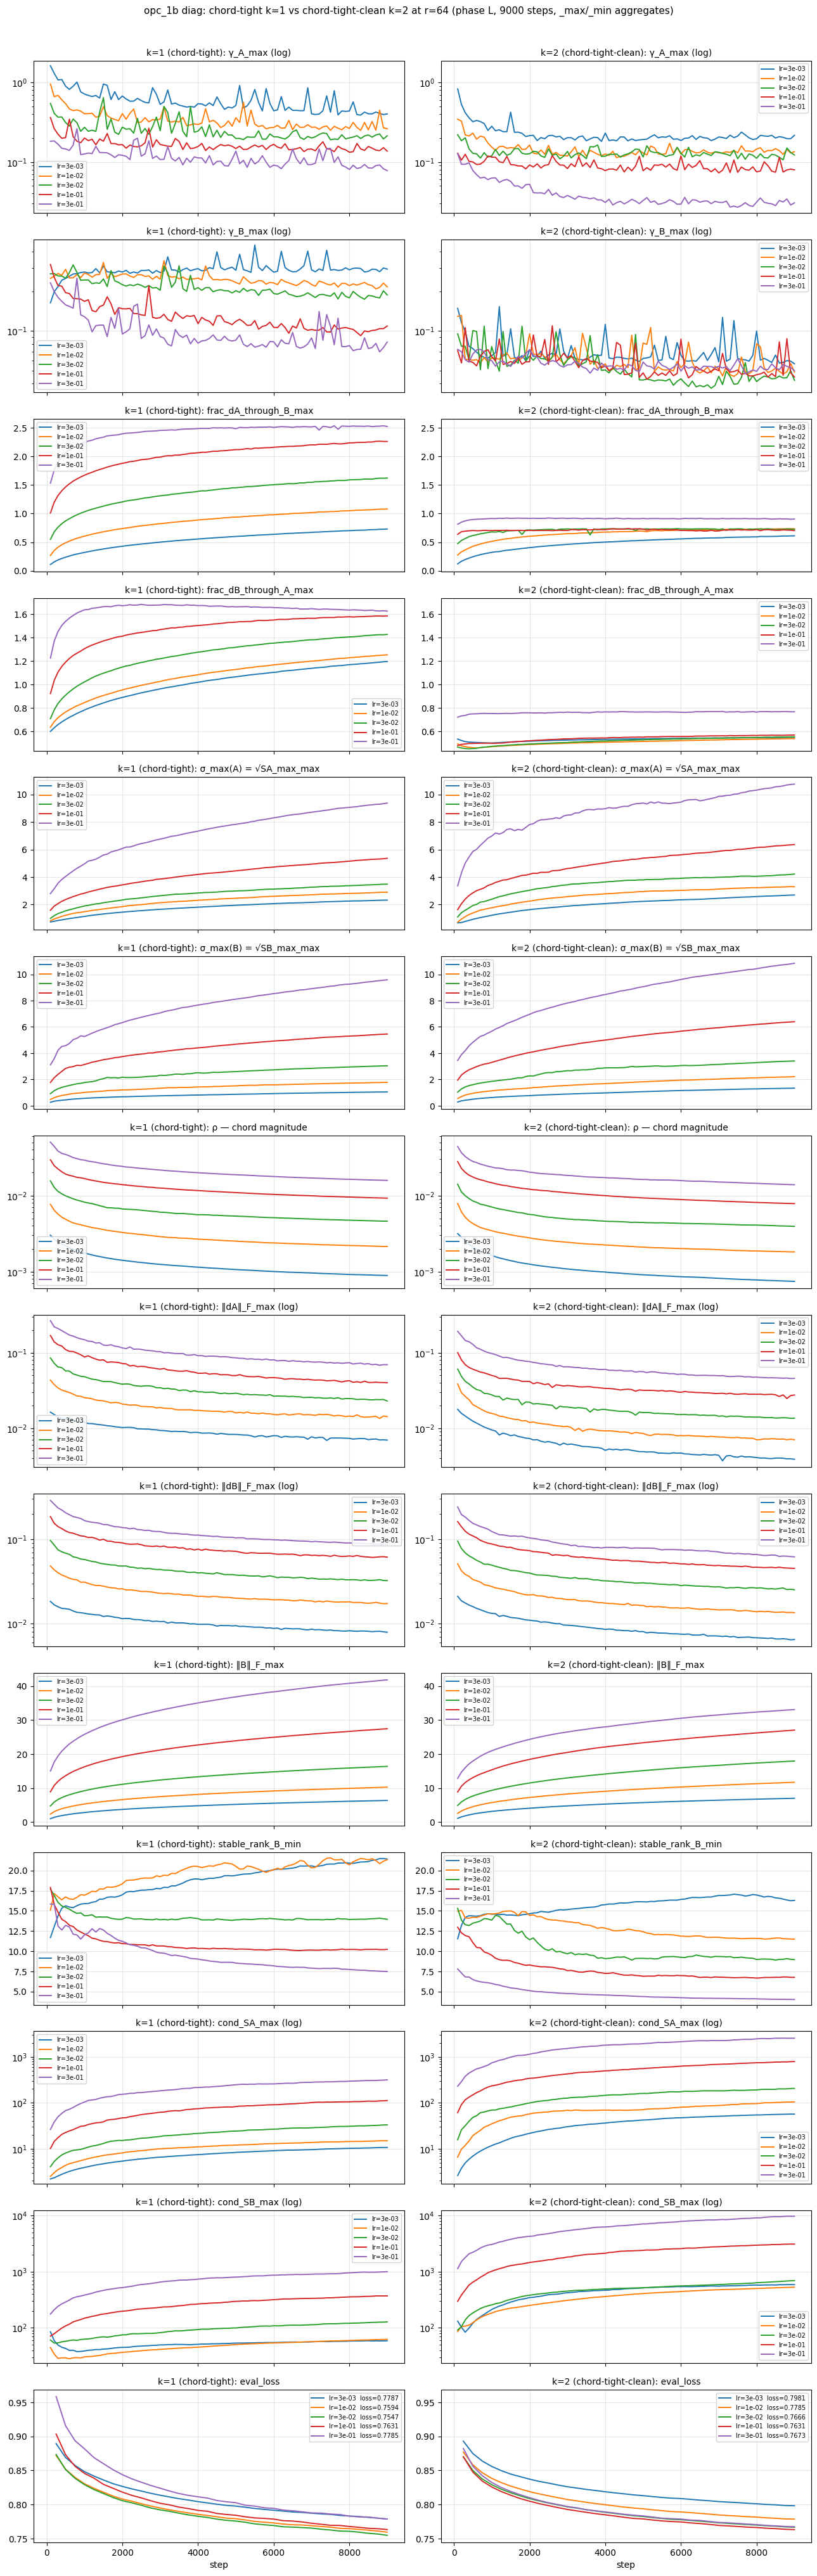

In [16]:
render(K1_R64, K2_R64, rank=64)


## r=256

In [17]:
K1_R256 = load_lr_curves(TIGHT, 256, k_target=1)
K2_R256 = load_lr_curves(CLEAN, 256, k_target=2)
_report('chord-tight k=1 r=256', K1_R256)
_report('chord-tight-clean k=2 r=256', K2_R256)


  [loader] excluded 156 run(s): 11 for 'Superseded by later chord-tight runs at the same cfg; +0.01 above seed cluster. See log_00 entry.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_01.out, r64_chord_postfix_validation_4k_blackwell/log_02.out, r64_chord_postfix_validation_4k_blackwell/log_03.out, +8 more); 1 for 'Superseded by later chord-tight runs at the same cfg; runs systematically +0.01 above seed cluster from descendants of ef6b3bc. Legacy registry entry blanket-excluded commit 91122ce; we narrow to the affected group since the bug surface was specific to this validation sweep.' (e.g. r64_chord_postfix_validation_4k_blackwell/log_00.out); 7 for 'buggy ε_rel (contam rerun cleanup, pre-λ_max-fix)' (e.g. eps_rel_lr_tuned_4k_blackwell/log_00.out, eps_rel_lr_tuned_4k_blackwell/log_01.out, eps_rel_lr_tuned_4k_blackwell/log_02.out, +4 more); 8 for 'buggy ε_rel (precond_delta_relative fix applied but pre-λ_max-fix (9677abe))' (e.g. chord_tight_k3_eps_rel_1e-2_r16r64_lr_sweep_4k_

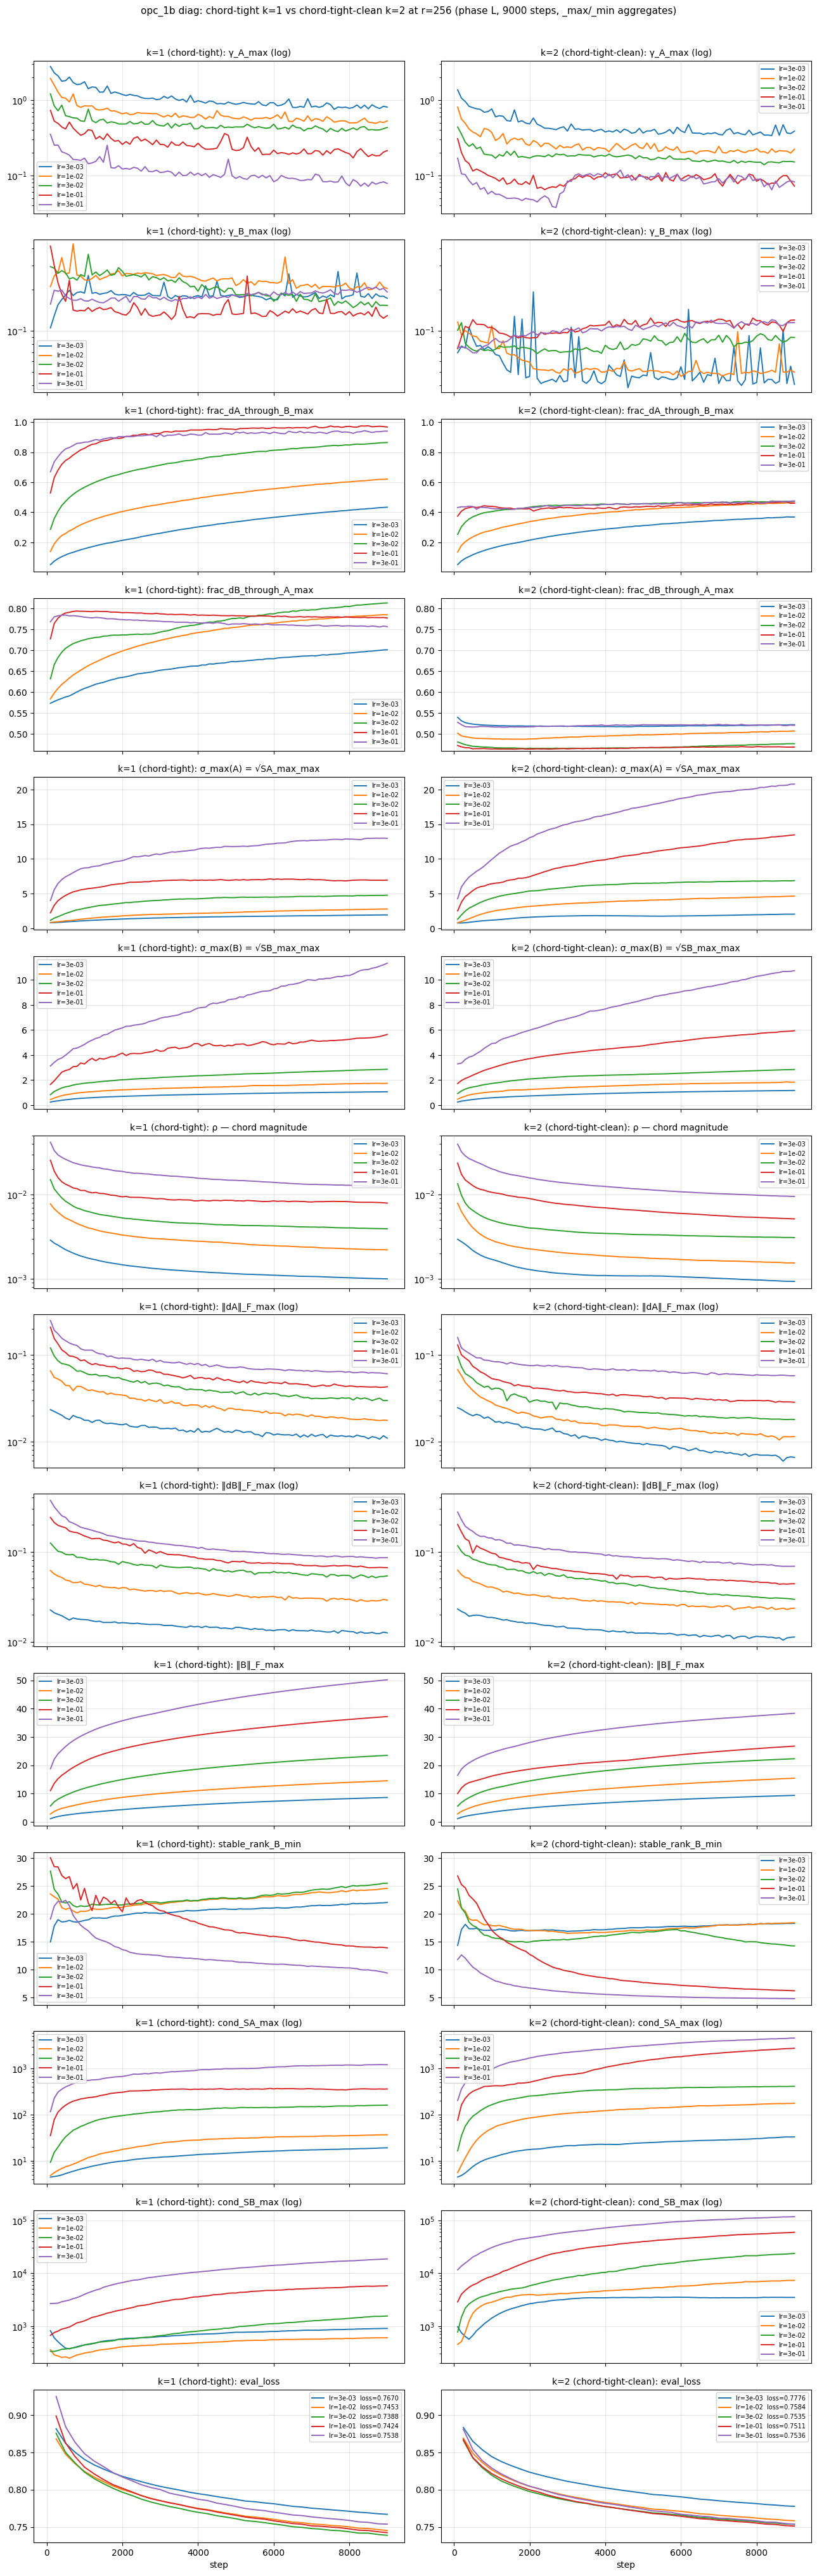

In [18]:
render(K1_R256, K2_R256, rank=256)
